# MKA-MLF, Lab_08 - RNN

Recurrent Neural Networks, are a class of artificial neural networks designed to recognize patterns in sequences of data, such as text, genomes, handwriting, or spoken words. Unlike traditional neural networks, which assume all inputs (and outputs) are independent of each other, RNNs are designed to recognize sequential or temporal patterns, making them especially suited for tasks like language modeling, speech recognition, and time series prediction.

## Exercise 1 - Time Series Forecasting

### 1.0 Import Libraries

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, SimpleRNN
from tensorflow.keras.optimizers import Adam

### 1.1 Generating dataset

In [41]:
def generate_time_series(batch_size, n_steps):
  freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
  time = np.linspace(0,1,n_steps)

  series = 0.5 * np.sin((time - offsets1) * (freq1*10 + 10))
  series += 0.2 * np.sin((time - offsets2) * (freq2*20 + 20))
  series += 0.1 * (np.random.rand(batch_size, n_steps)- 0.5)
  return series[..., np.newaxis].astype(np.float32)

In [42]:
data_size = 10000
n_steps = 50
np.random.seed(0)

series = generate_time_series(data_size, n_steps + 1)

### 1.2 Train/Valid/Test split

In [43]:
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

In [44]:
no_training_epochs = 5

### 1.3 Data examination

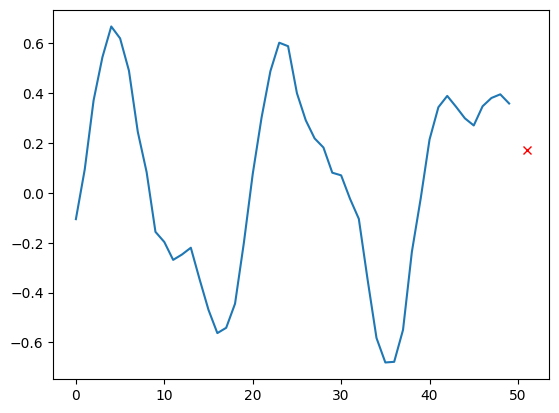

In [45]:
plt.figure()
plt.plot(X_train[0])
plt.plot(n_steps+1, y_train[0], 'rx')

### 1.4 Simple Linear model

In [46]:
# Model definition
model_linear = Sequential()
model_linear.add(Flatten(input_shape=(50,1)))
model_linear.add(Dense(1, activation = None))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [47]:
# Model building

learning_rate = 0.001
optimizer = Adam(learning_rate)
model_linear.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mean_squared_error'])

In [48]:
model_linear.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [49]:
# Model training

history_linear = model_linear.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0655 - mean_squared_error: 0.0655 - val_loss: 0.0356 - val_mean_squared_error: 0.0356
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0270 - mean_squared_error: 0.0270 - val_loss: 0.0196 - val_mean_squared_error: 0.0196
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0168 - mean_squared_error: 0.0168 - val_loss: 0.0133 - val_mean_squared_error: 0.0133
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0127 - mean_squared_error: 0.0127 - val_loss: 0.0106 - val_mean_squared_error: 0.0106
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0105 - mean_squared_error: 0.0105 - val_loss: 0.0091 - val_mean_squared_error: 0.0091


In [50]:
def plot_function(history):
  plt.figure()

  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='validation_loss')
  plt.legend()
  plt.grid()
  plt.xlim([0,no_training_epochs-1])
  plt.xlabel('epochs')

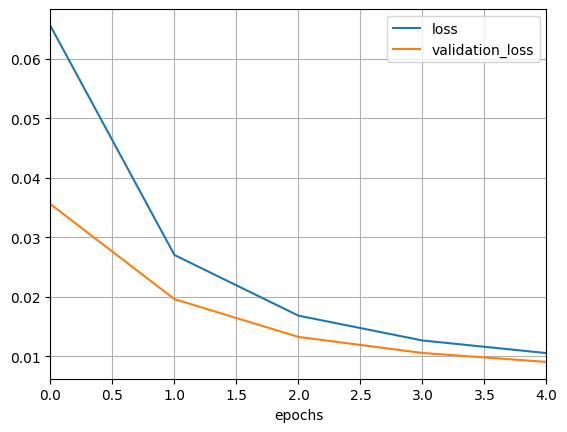

In [51]:
plot_function(history_linear)

In [52]:
score = model_linear.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.009093337692320347
Test MSE:  0.009093337692320347


### 1.5 Simple RNN Model

In [53]:
model_simple_rnn = Sequential()
model_simple_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [54]:
learning_rate_simple_rnn = 0.001
optimizer_simple_rnn = Adam(learning_rate_simple_rnn)
model_simple_rnn.compile(loss='mean_squared_error', optimizer=optimizer_simple_rnn, metrics=['mean_squared_error'])

In [55]:
history_simple_rnn = model_simple_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0181 - mean_squared_error: 0.0181 - val_loss: 0.0132 - val_mean_squared_error: 0.0132
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0122 - mean_squared_error: 0.0122 - val_loss: 0.0115 - val_mean_squared_error: 0.0115
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0112 - mean_squared_error: 0.0112 - val_loss: 0.0114 - val_mean_squared_error: 0.0114
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0110 - mean_squared_error: 0.0110 - val_loss: 0.0114 - val_mean_squared_error: 0.0114
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0110 - mean_squared_error: 0.0110 - val_loss: 0.0114 - val_mean_squared_error: 0.0114


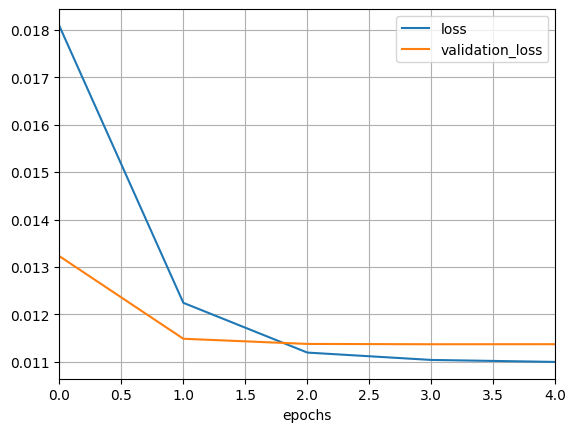

In [56]:
plot_function(history_simple_rnn)

### 1.5 Deep RNN Model

In [57]:
model_deep_rnn = Sequential()
model_deep_rnn.add(SimpleRNN(20, return_sequences = True, input_shape=[50, 1]))
model_deep_rnn.add(SimpleRNN(20, return_sequences = True))
model_deep_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

In [58]:
learning_rate_deep_rnn = 0.001
optimizer_deep_rnn = Adam(learning_rate_deep_rnn)
model_deep_rnn.compile(loss='mean_squared_error', optimizer=optimizer_deep_rnn, metrics=['mean_squared_error'])

In [59]:
history_deep_rnn = model_deep_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0694 - mean_squared_error: 0.0694 - val_loss: 0.0102 - val_mean_squared_error: 0.0102
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0069 - mean_squared_error: 0.0069 - val_loss: 0.0051 - val_mean_squared_error: 0.0051
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0050 - mean_squared_error: 0.0050 - val_loss: 0.0044 - val_mean_squared_error: 0.0044
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0043 - mean_squared_error: 0.0043 - val_loss: 0.0048 - val_mean_squared_error: 0.0048
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0040 - mean_squared_error: 0.0040 - val_loss: 0.0037 - val_mean_squared_error: 0.0037


In [60]:
score = model_deep_rnn.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.0037114520091563463
Test MSE:  0.0037114520091563463


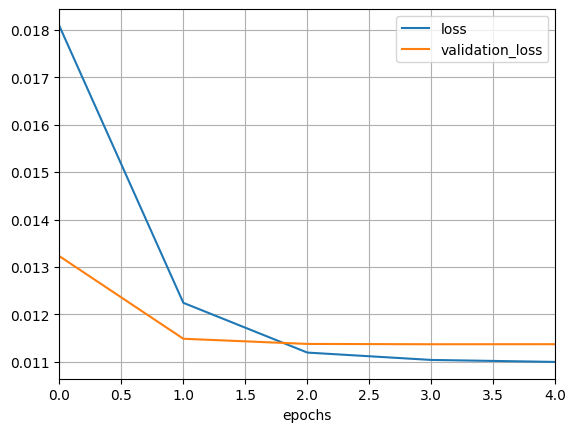

In [61]:
plot_function(history_simple_rnn)

## Exercise 2 - The movie review




Based on the written rewiev, classify if the movie if good or bad

### 2.0 - Import libraries

In [62]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow import keras
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, SimpleRNN, GRU
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam

### 2.1 - Load dataset

In [63]:
vocabulary_size = 10000
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=vocabulary_size)

### 2.2 - Dataset examination

In [64]:
word_index = keras.datasets.imdb.get_word_index()
id_to_word = {id_ + 3:word for word, id_ in word_index.items()}
for id_, token in enumerate(("<pad>", "<sos>", "<unk>")):
  id_to_word[id_] = token

In [65]:
single_sequence = " ".join([id_to_word[id_] for id_ in X_train[0][:]])

In [66]:
single_sequence

"<sos> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <unk> is an amazing actor and now the same being director <unk> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <unk> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <unk> to the two little boy's that played the <unk> of norman and paul they were just brilliant children are often left out of the <unk> list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what

In [67]:
max_length = 150  # Define the maximum length of a review
X_train = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=max_length, padding='post', truncating='post', value=0)
X_test = keras.preprocessing.sequence.pad_sequences(X_test, maxlen=max_length, padding='post', truncating='post', value=0)

In [68]:
embed_size = 256


def build_model(core_type, vocabulary_size, embed_size):
    model = keras.models.Sequential([
        keras.layers.Embedding(vocabulary_size, embed_size, input_shape=[None]),
        core_type(128, return_sequences=True),
        core_type(128),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

In [69]:
experiments = [
    ("SimpleRNN", keras.layers.SimpleRNN),
    ("LSTM", keras.layers.LSTM),
    ("GRU", keras.layers.GRU)
]

results = []
histories = {}

In [77]:
results = []
histories = {}

for name, core_layer in experiments:
    model = build_model(core_layer, vocabulary_size, embed_size)
    optimizer = Adam(learning_rate=0.001)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    
    # Stop training when validation loss no longer improves.
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        mode='min',
        patience=2,
        restore_best_weights=True,
        verbose=1
    )
    
    print(f"\nTraining {name}...")
    history = model.fit(
        X_train,
        y_train,
        epochs=10,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=1
    )
    histories[name] = history

    score = model.evaluate(X_test, y_test, verbose=0)
    results.append({
        'Model': name,
        'Test Loss': float(score[0]),
        'Test Accuracy (%)': float(score[1] * 100),
        'Best Val Accuracy (%)': float(max(history.history['val_accuracy']) * 100)
    })


Training SimpleRNN...
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.5010 - loss: 0.7007 - val_accuracy: 0.5698 - val_loss: 0.6849
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.5349 - loss: 0.6909 - val_accuracy: 0.5388 - val_loss: 0.6893
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.5628 - loss: 0.6768 - val_accuracy: 0.5222 - val_loss: 0.7072
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.

Training LSTM...
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.5419 - loss: 0.6850 - val_accuracy: 0.5018 - val_loss: 0.6957
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.7038 - loss: 0.5516 - val_accuracy: 0.8430 - val_loss: 0.3780
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8849 - loss: 0.2902 - val_accuracy: 0.8562 - val_loss: 0.3457
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9327 - loss: 0.1973 - val_ac

In [78]:
results_sorted = sorted(results, key=lambda x: x['Test Accuracy (%)'], reverse=True)

print('\nComparison of recurrent cores on IMDb sentiment dataset:')
for item in results_sorted:
    print(
        f"{item['Model']:>9} | "
        f"Test Acc: {item['Test Accuracy (%)']:.2f}% | "
        f"Best Val Acc: {item['Best Val Accuracy (%)']:.2f}% | "
        f"Test Loss: {item['Test Loss']:.4f}"
    )


Comparison of recurrent cores on IMDb sentiment dataset:
      GRU | Test Acc: 84.94% | Best Val Acc: 86.24% | Test Loss: 0.3389
     LSTM | Test Acc: 83.63% | Best Val Acc: 85.98% | Test Loss: 0.3812
SimpleRNN | Test Acc: 57.39% | Best Val Acc: 56.98% | Test Loss: 0.6850


In [79]:
best_model = results_sorted[0]['Model']
print(f"\nBest performing recurrent core: {best_model}")


Best performing recurrent core: GRU


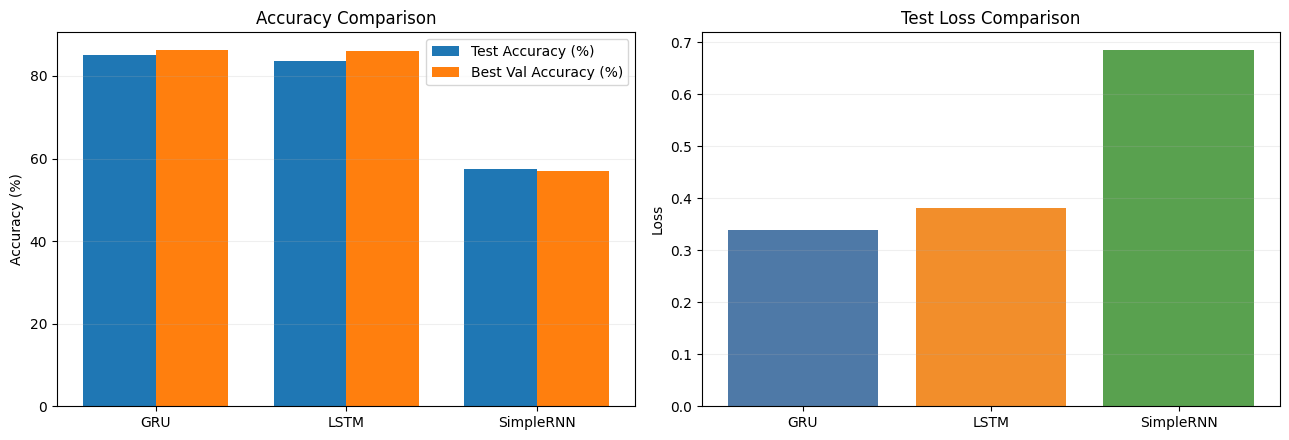

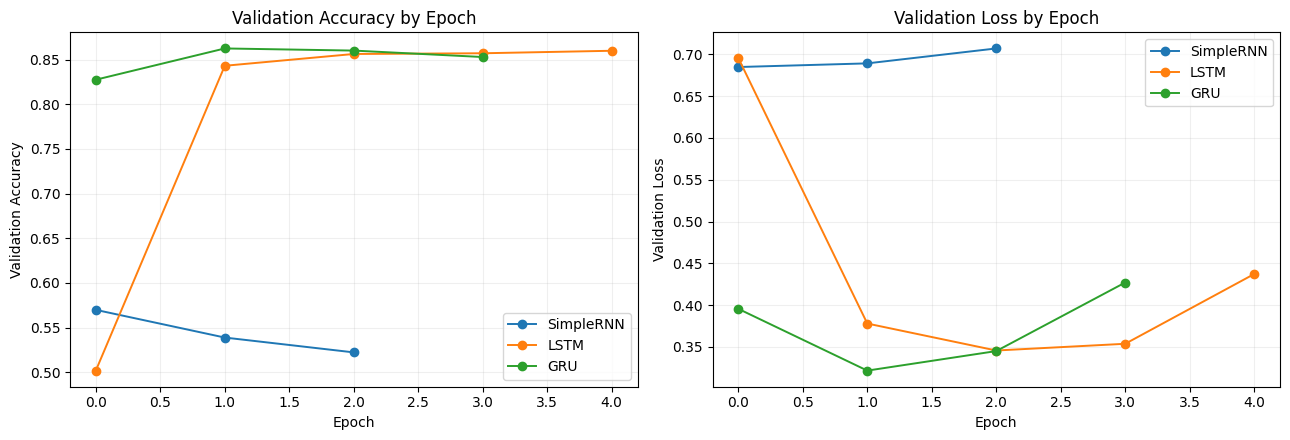

In [80]:
import matplotlib.pyplot as plt

if not results_sorted or not histories:
    raise ValueError("Run the training/comparison cells first so results are available.")

models = [item['Model'] for item in results_sorted]
test_acc = [item['Test Accuracy (%)'] for item in results_sorted]
best_val_acc = [item['Best Val Accuracy (%)'] for item in results_sorted]
test_loss = [item['Test Loss'] for item in results_sorted]

# Figure 1: metric comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

x = list(range(len(models)))
bar_width = 0.38
axes[0].bar([i - bar_width / 2 for i in x], test_acc, width=bar_width, label='Test Accuracy (%)')
axes[0].bar([i + bar_width / 2 for i in x], best_val_acc, width=bar_width, label='Best Val Accuracy (%)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Accuracy Comparison')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.2)

axes[1].bar(models, test_loss, color=['#4e79a7', '#f28e2b', '#59a14f'][:len(models)])
axes[1].set_ylabel('Loss')
axes[1].set_title('Test Loss Comparison')
axes[1].grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

# Figure 2: validation learning curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for name, history in histories.items():
    axes[0].plot(history.history['val_accuracy'], marker='o', linewidth=1.4, label=name)
axes[0].set_title('Validation Accuracy by Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.2)

for name, history in histories.items():
    axes[1].plot(history.history['val_loss'], marker='o', linewidth=1.4, label=name)
axes[1].set_title('Validation Loss by Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

TASK: Modify structure, change the core of the network from RNN to LSTM and GRU. Compare the results.